In [ ]:
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt
from uphate.uphate import (
    get_phate_embedding,
    get_phate_embedding_jit,
    get_phate_embedding_bootstrap,
)
from uphate.utils import align_embeddings
from phate.tree import gen_dla

In [3]:
X, labels = gen_dla(n_branch=10)

In [4]:
embeddings = get_phate_embedding_bootstrap(
    jnp.array(X),
    jax.random.key(20),
    n_samples=20,
    t=20,
)

100%|██████████| 20/20 [02:12<00:00,  6.60s/it]


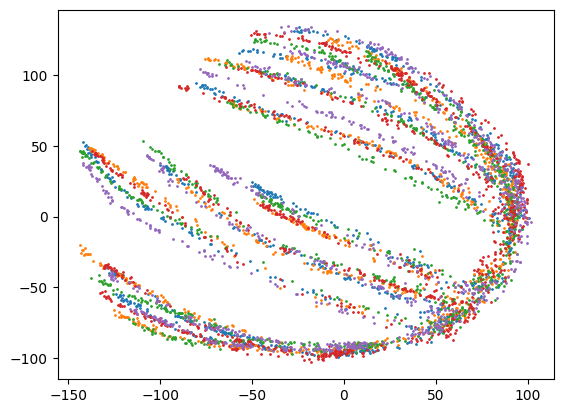

In [37]:
aligned_embeddings = jnp.array(list(map(lambda e: align_embeddings(embeddings[0], e), embeddings)))
for emb in aligned_embeddings[:5]:
    plt.scatter(*emb.T, s=1)

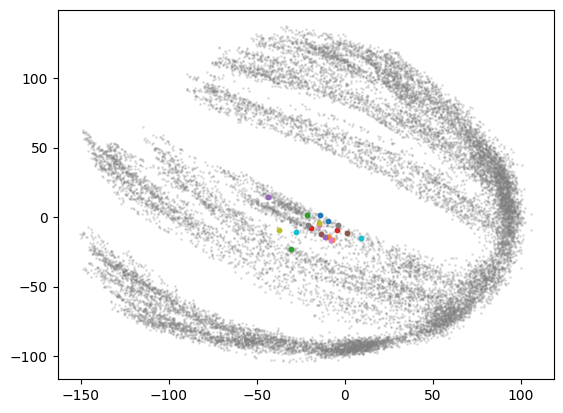

In [33]:
from random import randint


index = randint(0, len(X))

for emb in aligned_embeddings:
    plt.scatter(*emb.T, c="gray", alpha=0.2, s=1)

for emb in aligned_embeddings:
    plt.scatter(*emb[index].T, s=10)